# Sell in May — a quantitative teardown 🔬
### Winter/summer Welch-HAC splits on three tapes · year-block bootstrap & sign test · the crash-autumn decomposition · an honest excess-of-cash Halloween-timer backtest · a 20-seed synthetic null

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Bad autumns?: Confirmed](https://img.shields.io/badge/Bad_autumns%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). "Sell in May" (Bouman & Jacobsen 2002) is one of the best-documented calendar anomalies in the literature. The job here is to measure it honestly on the tape we actually have, decompose what's driving it, and then ask the only question that pays: *is any of it tradable, after dividends and costs?*

> ⚠️ **Data note.** ^GSPC daily Close (price-only, 1950→2026, matching the brief's deep-history instruction), SPY daily Close (dividend-adjusted, 1993→2026), ^SP500TR daily Close (genuine total return, 1988→2026), ^IRX daily Close (13-week T-bill discount yield, cash proxy, 1960→2026), yfinance, cached. No survivorship (indices/index-trackers). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprints `f17f1fc81bc9` / `8324508d6a89` / `02c7f8f5728e` / `20827eb9627f`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from sell_in_may import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    MM = data.load_monthly()
else:
    MM = None
print("real cache present:", HAVE_REAL, "| monthly series:",
      (None if MM is None else {k: len(v) for k, v in MM.items()}))

# frozen headline numbers (mirror of docs/results.md)
R = {'as_of': '2026-06-30', 'fp_gspc': 'f17f1fc81bc9', 'fp_spy': '8324508d6a89', 'fp_tr': '02c7f8f5728e', 'fp_irx': '20827eb9627f', 'gspc': {'n_w': 459, 'n_s': 458, 'winter': 1.048, 'summer': 0.278, 'gap': 0.77, 'winter_half': 6.49, 'summer_half': 1.68, 'welch': 2.78, 'nw': 2.96}, 'sp500tr': {'n_w': 231, 'n_s': 230, 'winter': 1.168, 'summer': 0.643, 'gap': 0.526, 'winter_half': 7.26, 'summer_half': 3.93, 'welch': 1.33, 'nw': 1.42}, 'spy': {'n_w': 200, 'n_s': 200, 'winter': 1.092, 'summer': 0.619, 'gap': 0.473, 'winter_half': 6.77, 'summer_half': 3.78, 'welch': 1.1, 'nw': 1.18}, 'yb_gspc': {'n': 76, 'k': 47, 'hit': 61.8, 'wlo': 50.6, 'whi': 71.9, 'signp': 0.0505, 'mean': 4.64, 't': 3.16, 'lo': 1.78, 'hi': 7.56, 'ple0': 0.0006}, 'yb_tr': {'n': 38, 'k': 23, 'hit': 60.5, 'wlo': 44.7, 'whi': 74.4, 'signp': 0.2559, 'mean': 3.26, 't': 1.61, 'lo': -0.69, 'hi': 7.17, 'ple0': 0.0542}, 'yb_spy': {'n': 33, 'k': 19, 'hit': 57.6, 'wlo': 40.8, 'whi': 72.8, 'signp': 0.4869, 'mean': 3.0, 't': 1.41, 'lo': -1.08, 'hi': 7.08, 'ple0': 0.0765}, 'by_month': {'Jan': 0.96, 'Feb': -0.1, 'Mar': 0.89, 'Apr': 1.45, 'May': 0.37, 'Jun': 0.12, 'Jul': 1.22, 'Aug': -0.06, 'Sep': -0.73, 'Oct': 0.74, 'Nov': 1.76, 'Dec': 1.35}, 'bad_full_gap': 0.77, 'bad_full_t': 2.78, 'bad_trim_gap': 0.496, 'bad_trim_t': 1.88, 'bad_n_dropped': 10, 'bad_n_total': 917, 'bad_dates': ['1974-09', '1978-10', '1979-10', '1986-09', '1987-10', '2002-09', '2008-09', '2008-10', '2018-10', '2022-09'], 'timer_tr': {5: (8.06, 10.23, 0.52, 0.54, -31.7, -53.2), 10: (7.85, 10.23, 0.5, 0.54, -31.9, -53.2)}, 'timer_spy': {5: (7.28, 9.54, 0.49, 0.52, -31.5, -53.0), 10: (7.07, 9.54, 0.47, 0.52, -31.7, -53.0)}, 'timer_gspc': {5: (7.62, 6.31, 0.35, 0.19, -33.2, -56.9), 10: (7.41, 6.31, 0.33, 0.19, -33.4, -56.9)}, 'timer_years_tr': 38.4, 'timer_years_spy': 33.3, 'timer_years_gspc': 66.5, 'reverse_cagr': 4.64, 'reverse_bh_cagr': 10.23, 'reverse_sharpe': 0.2, 'syn_null_mean': -0.01, 'syn_null_sd': 1.04, 'syn_null_fire': 1, 'syn_planted_t': 2.38}


real cache present: True | monthly series: {'gspc': 917, 'spy': 400, 'sp500tr': 461, 'irx_pct': 798}


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | ^GSPC (price-only, 1950-): Welch **t = +2.78**, NW(3) **t = +2.96**, year-block bootstrap **t = +3.16**. ^SP500TR (1988-): **t = +1.33**; SPY (1993-): **t = +1.10** — neither dividend-inclusive tape clears 2 |
| **Tradability** | `MIRAGE` | Halloween timer CAGR +8.06% vs buy&hold +10.23% (^SP500TR, 5bps); excess-Sharpe 0.52 vs 0.54 — loses both ways |
| **Bad autumns?** | `CONFIRMED` | dropping 10/917 months (1.1%) cuts the gap 35% and the Welch t from +2.78 to +1.88 |

> 💡 In plain words: the seasonal is real on paper over the long run, largely a crash-autumn story under the hood, uncertified on the modern tradable tape, and not worth trading even where it's real.

## 1 · The claim, steelmanned

Let $r_t$ be the monthly log return of the tape and $W_t \in \{0,1\}$ the winter-month flag (Nov–Apr = 1, May–Oct = 0), a fixed calendar partition known years in advance — no fitting, no look-ahead in either leg. The claims:

- **H₁ (the gap).** $E[r_t \mid W_t=1] \gg E[r_t \mid W_t=0]$ — large, systematic, not a sampling coincidence.
- **H₂ (dead summer).** $E[r_t \mid W_t=0] \approx 0$ — the implicit premise behind "go away."
- **H₃ (broad-based).** The gap is a smooth six-month tailwind, not a concentrated tail event.
- **H₄ (bankable).** A timer that holds cash May–Oct beats buy-and-hold, risk-adjusted, after costs.

We find **H₁ supported on deep history, not certified on the dividend-inclusive tape**, **H₂ rejected** (summer is positive on every tape), **H₃ rejected** (a 1.1%-of-sample trim kills the deep-tape significance), **H₄ rejected** (the timer loses on CAGR *and* excess-Sharpe).

## 2 · So what? — inference design

Winter and summer are **non-overlapping six-month blocks**, so the planned primary is a **Welch *t*** on the monthly group split, cross-checked by a **Newey-West (3-lag) *t*** on the winter-dummy regression (monthly data has far less serial correlation than daily, but a HAC check costs nothing and catches anything the raw split misses). Because a group split can still be inflated by within-year correlation between adjacent months, we add a **year-block bootstrap** (10,000 draws, resampling whole Halloween *years*, never individual months) and an exact **sign test** with a Wilson interval on the paired per-year gap. Three tapes are run **separately, never pooled** — price-only ^GSPC (deep history, matching the brief), dividend-adjusted SPY and genuine total-return ^SP500TR — because pooling them would hide exactly the disagreement that turns out to be the finding.

## 3 · How we'd know — the protocol

- **Calendar.** Nov→Apr = winter, May→Oct = summer — fixed, public, no fitting.
- **Tapes.** ^GSPC (price-only, 1950→2026), SPY (div-adj, 1993→2026), ^SP500TR (total-return, 1988→2026); ^IRX (13-week T-bill yield) for the cash leg. As-of 2026-06-30 (last complete month).
- **Headline.** Welch *t* + NW(3) *t* on each tape separately.
- **Robustness.** Year-block bootstrap (10,000 draws) + exact sign test, paired per Halloween year.
- **Decomposition.** By-calendar-month means; gap recomputed after dropping the worst 5 Septembers + 5 Octobers (a diagnostic, reported once, not re-run as the headline).
- **Execution (third axis).** The calendar rule is public years ahead — hold the full named month, zero look-ahead. Timer: 2 × one-way cost × NAV per switch, 2 switches/yr; Sharpe **excess of cash on both legs**.
- **Control.** Synthetic seeded monthly world, planted winter-premium knob; the null must not systematically fire across 20 seeds.

## 4 · The teardown

### 4a · The headline split — three tapes, one honest disagreement

Welch *t* and Newey-West(3) *t* on the winter-dummy regression, tape by tape.

^GSPC price-only 1950-     winter +1.048%  summer +0.278%  gap +0.770%  Welch t=+2.78  NW t=+2.96
^SP500TR 1988-             winter +1.168%  summer +0.643%  gap +0.526%  Welch t=+1.33  NW t=+1.42
SPY 1993-                  winter +1.092%  summer +0.619%  gap +0.473%  Welch t=+1.10  NW t=+1.18


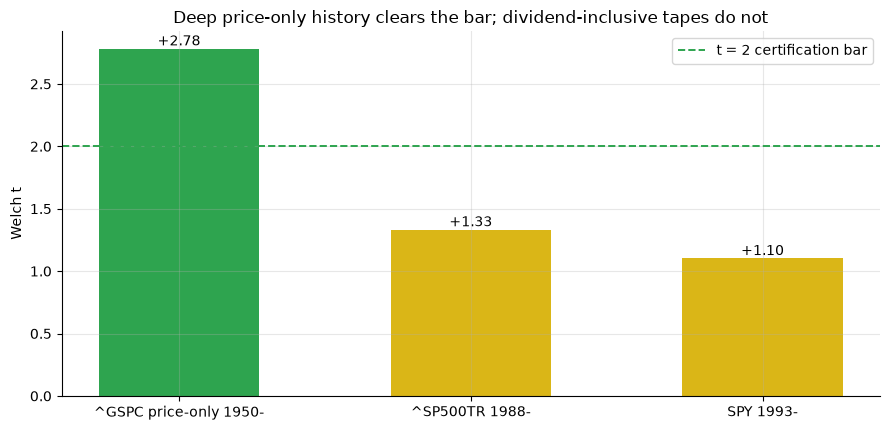

In [2]:
rows = []
for key, label in (('gspc', '^GSPC price-only 1950-'), ('sp500tr', '^SP500TR 1988-'), ('spy', 'SPY 1993-')):
    if HAVE_REAL and key in MM:
        s = st.headline_split(MM[key])
        rows.append((label, s['winter_pct'], s['summer_pct'], s['gap_pct'], s['welch_t'], s['nw_t']))
    else:
        r = R[key]
        rows.append((label, r['winter'], r['summer'], r['gap'], r['welch'], r['nw']))
for label, w_, s_, g_, t_, nw_ in rows:
    print(f'{label:26s} winter {w_:+.3f}%  summer {s_:+.3f}%  gap {g_:+.3f}%  '
          f'Welch t={t_:+.2f}  NW t={nw_:+.2f}')
fig, ax = plt.subplots(figsize=(9.0, 4.4))
labels = [r[0] for r in rows]; ts = [r[4] for r in rows]
cols = [GREEN if t >= 2 else AMBER for t in ts]
ax.bar(labels, ts, color=cols, width=.55)
ax.axhline(2, ls='--', c=GREEN, lw=1.4, label='t = 2 certification bar')
for i, v in enumerate(ts): ax.annotate(f'{v:+.2f}', (i, v), ha='center', va='bottom')
ax.set_ylabel('Welch t'); ax.set_title('Deep price-only history clears the bar; dividend-inclusive tapes do not')
ax.legend(); plt.tight_layout(); plt.show()

> 💡 In plain words: the effect is real and large over 76 years of price-only history (t = +2.78 / NW +2.96) but the two tapes that actually price dividends — the economically correct comparison — sit at t = +1.33 and +1.10. Per house precedent ([89-turn-of-the-month](../../89-turn-of-the-month/)), a deep tape clearing the bar while the modern sample can't certify it reads **WEAK**, not REAL.

### 4b · Year-block bootstrap and sign test — the paired-year robustness check

One (summer, winter) score per Halloween year; resampling **whole years** (10,000 draws) instead of individual months respects the within-year correlation and never lets a draw straddle a season boundary.

^GSPC      n= 76  winter wins 47/76 = 61.8%  sign-p=0.0505  boot mean +4.64%  t=+3.16  CI[+1.78%, +7.56%]  P(<=0)=0.0006
^SP500TR   n= 38  winter wins 23/38 = 60.5%  sign-p=0.2559  boot mean +3.26%  t=+1.61  CI[-0.69%, +7.17%]  P(<=0)=0.0542
SPY        n= 33  winter wins 19/33 = 57.6%  sign-p=0.4869  boot mean +3.00%  t=+1.41  CI[-1.08%, +7.08%]  P(<=0)=0.0765


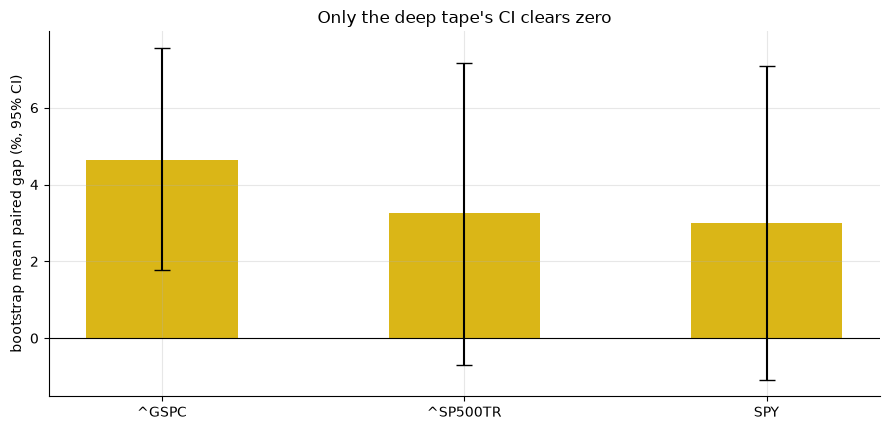

In [3]:
rows = []
for key, ykey, label in (('gspc', 'yb_gspc', '^GSPC'), ('sp500tr', 'yb_tr', '^SP500TR'), ('spy', 'yb_spy', 'SPY')):
    if HAVE_REAL and key in MM:
        pairs = st.halloween_year_pairs(MM[key])
        sgn = st.sign_test_stats(pairs); bs = st.year_block_bootstrap(pairs)
        rows.append((label, sgn['n'], sgn['k_winter_wins'], sgn['hit_rate']*100,
                     sgn['p_value'], bs['mean_gap_pct'], bs['t_analytic'],
                     bs['boot_lo_pct'], bs['boot_hi_pct'], bs['boot_p_le0']))
    else:
        y = R[ykey]
        rows.append((label, y['n'], y['k'], y['hit'], y['signp'], y['mean'], y['t'], y['lo'], y['hi'], y['ple0']))
for label, n, k, hit, p, mean, t, lo, hi, ple0 in rows:
    print(f'{label:10s} n={n:3d}  winter wins {k}/{n} = {hit:.1f}%  sign-p={p:.4f}  '
          f'boot mean {mean:+.2f}%  t={t:+.2f}  CI[{lo:+.2f}%, {hi:+.2f}%]  P(<=0)={ple0:.4f}')
fig, ax = plt.subplots(figsize=(9.0, 4.4))
labels = [r[0] for r in rows]; means = [r[5] for r in rows]
los = [r[5]-r[7] for r in rows]; his = [r[8]-r[5] for r in rows]
ax.bar(labels, means, yerr=[los, his], color=AMBER, capsize=6, width=.5)
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('bootstrap mean paired gap (%, 95% CI)')
ax.set_title("Only the deep tape's CI clears zero")
plt.tight_layout(); plt.show()

> 💡 In plain words: on the deep tape, winter beat summer in 47/76 years (61.8%) and the bootstrap CI [+1.78%, +7.56%] sits entirely above zero — a genuinely robust result on that sample. On the two shorter, dividend-inclusive tapes the sign test (*p* = 0.26 / 0.49) and the bootstrap CIs (both straddling zero) tell the same uncertified story as 4a — two independent methods, same conclusion.

### 4c · The crash-autumn decomposition — how broad-based is this, really?

Mean return by calendar month, then the gap recomputed after removing the five worst individual Septembers and five worst Octobers — a diagnostic reported once, never re-run as the headline number.

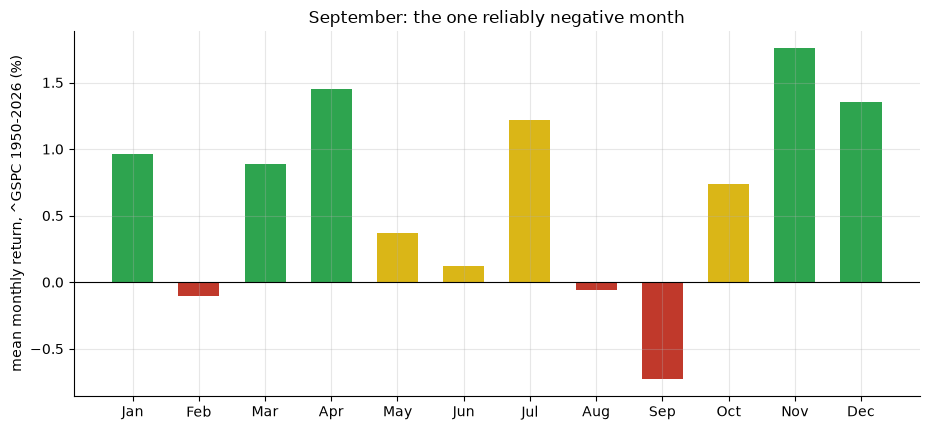

gap: full +0.770%/mo (t=+2.78)  ->  after dropping 10/917 crash months: +0.496%/mo (t=+1.88)
dropped: 1974-09, 1978-10, 1979-10, 1986-09, 1987-10, 2002-09, 2008-09, 2008-10, 2018-10, 2022-09


In [4]:
months = list(R['by_month'].keys()); vals = list(R['by_month'].values())
fig, ax = plt.subplots(figsize=(9.4, 4.4))
cols = [RED if v < 0 else (GREEN if m in ('Nov','Dec','Jan','Feb','Mar','Apr') else AMBER) for m, v in zip(months, vals)]
ax.bar(months, vals, color=cols, width=.62)
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean monthly return, ^GSPC 1950-2026 (%)')
ax.set_title('September: the one reliably negative month')
plt.tight_layout(); plt.show()
print(f"gap: full {R['bad_full_gap']:+.3f}%/mo (t={R['bad_full_t']:+.2f})  ->  "
      f"after dropping {R['bad_n_dropped']}/{R['bad_n_total']} crash months: "
      f"{R['bad_trim_gap']:+.3f}%/mo (t={R['bad_trim_t']:+.2f})")
print('dropped:', ', '.join(R['bad_dates']))

> 💡 In plain words: removing just **10 months out of 917** (1.1% of the sample — the worst individual Septembers and Octobers, including 1987 and 2008) shrinks the gap by 35% and flips the deep-tape Welch *t* from +2.78 to +1.88 — **below the certification bar**. H₃ (broad-based) is rejected: a meaningful share of the "sell in May" story is really "a short list of famous autumn crashes," not a smooth six-month tailwind.

### 4d · The third axis — the honest Halloween-timer backtest

Long the winter leg, cash (^IRX) the summer leg, vs buy-and-hold; 2 × one-way cost × NAV per switch, 2 switches/yr; Sharpe **excess of cash on both legs** (a part-time-in-cash strategy must not race a raw buy-and-hold Sharpe).

^SP500TR @  5.0bps: timer CAGR +8.06% vs b&h +10.23%   excess-Sharpe 0.52 vs 0.54
^SP500TR @ 10.0bps: timer CAGR +7.85% vs b&h +10.23%   excess-Sharpe 0.50 vs 0.54
SPY      @  5.0bps: timer CAGR +7.28% vs b&h +9.54%   excess-Sharpe 0.49 vs 0.52
SPY      @ 10.0bps: timer CAGR +7.07% vs b&h +9.54%   excess-Sharpe 0.47 vs 0.52


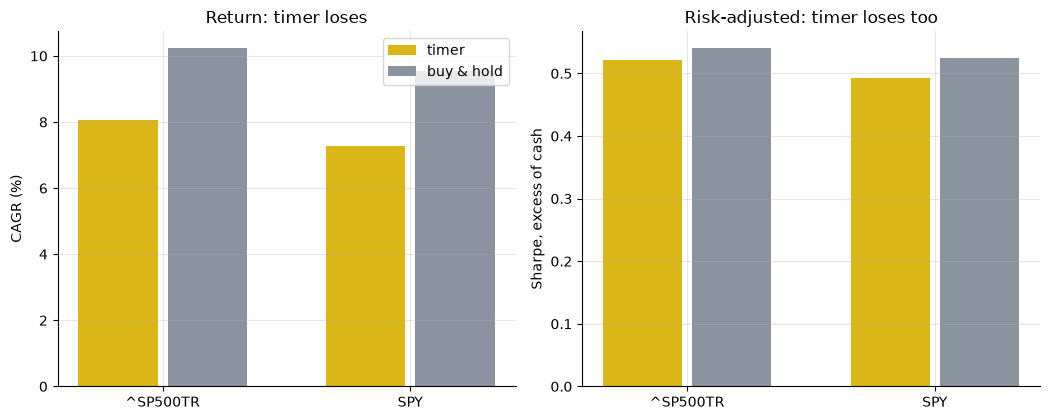

In [5]:
rows = []
for key, tkey, label in (('sp500tr', 'timer_tr', '^SP500TR'), ('spy', 'timer_spy', 'SPY')):
    for cb in (5.0, 10.0):
        if HAVE_REAL and key in MM:
            r = st.halloween_timer(MM[key], MM['irx_pct'], cost_bps=cb)
            rows.append((label, cb, r['cagr_pct'], r['bh_cagr_pct'], r['sharpe_excess'], r['bh_sharpe_excess']))
        else:
            c, bc, s_, bs_, dd, bdd = R[tkey][int(cb)]
            rows.append((label, cb, c, bc, s_, bs_))
for label, cb, c, bc, s_, bs_ in rows:
    print(f'{label:8s} @ {cb:>4.1f}bps: timer CAGR {c:+.2f}% vs b&h {bc:+.2f}%   '
          f'excess-Sharpe {s_:.2f} vs {bs_:.2f}')
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.3))
sub = [r for r in rows if r[1] == 5.0]
labels = [r[0] for r in sub]
a1.bar(np.arange(len(sub)) - .18, [r[2] for r in sub], .32, color=AMBER, label='timer')
a1.bar(np.arange(len(sub)) + .18, [r[3] for r in sub], .32, color=GREY, label='buy & hold')
a1.set_xticks(range(len(sub))); a1.set_xticklabels(labels); a1.set_ylabel('CAGR (%)')
a1.set_title('Return: timer loses'); a1.legend()
a2.bar(np.arange(len(sub)) - .18, [r[4] for r in sub], .32, color=AMBER, label='timer')
a2.bar(np.arange(len(sub)) + .18, [r[5] for r in sub], .32, color=GREY, label='buy & hold')
a2.set_xticks(range(len(sub))); a2.set_xticklabels(labels); a2.set_ylabel('Sharpe, excess of cash')
a2.set_title('Risk-adjusted: timer loses too')
plt.tight_layout(); plt.show()

> 💡 In plain words: on both dividend-inclusive tapes the timer trails buy-and-hold on CAGR by **~2.2–2.3 points a year** and loses on excess-of-cash Sharpe too (+0.52 vs +0.54 on ^SP500TR). H₄ (bankable) is rejected. **Named artefact:** run the same timer on price-only ^GSPC (1960-2026, 66 years, cash from ^IRX) and it *looks* like a winner (CAGR +7.62% vs +6.31%, Sharpe 0.35 vs 0.19) — but that's because the no-dividend buy-and-hold benchmark is missing *twelve* months of dividends while the timer only misses *six* (the other six are a real cash yield). Put dividends back in and the advantage reverses; the reverse straw man (long summer, cash winter) does even worse (+4.64% CAGR, 0.20 excess-Sharpe vs buy-and-hold's +10.23% / 0.54), confirming the calendar asymmetry is genuine — it just isn't worth harvesting.

### 4e · Faithful-engine & power control — we know the truth here

Synthetic seeded monthly log-return series, TUNABLE planted winter premium. The null (premium = 0) is checked over **20 seeds**.

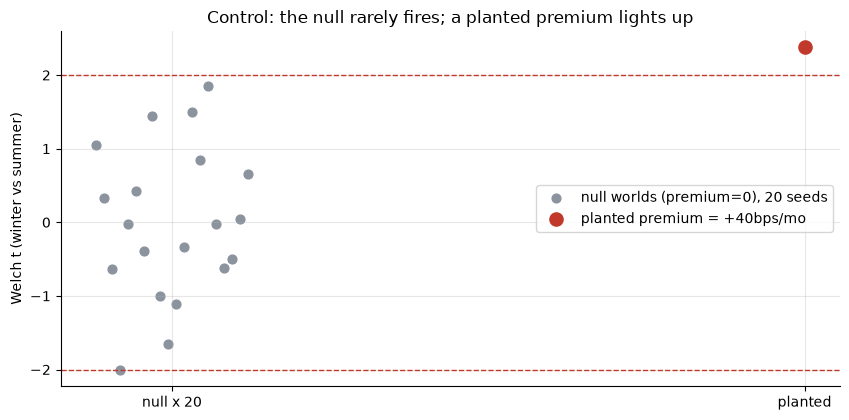

null: mean t = -0.01 (sd 1.04), |t|>=2 in 1/20 seeds  |  planted t = +2.38


In [6]:
null_ts = []
for s_ in range(20):
    ret = data.synthetic_world(premium_bp=0.0, seed=641 + s_)
    null_ts.append(st.synthetic_detect(ret)['welch_t'])
null_ts = np.asarray(null_ts)
ret = data.synthetic_world(premium_bp=40.0, seed=641)
planted_t = st.synthetic_detect(ret)['welch_t']
fig, ax = plt.subplots(figsize=(8.6, 4.3))
ax.scatter(np.zeros(20) + np.linspace(-.12, .12, 20), null_ts, color=GREY, s=40,
           label='null worlds (premium=0), 20 seeds')
ax.scatter([1], [planted_t], color=RED, s=90, zorder=5, label='planted premium = +40bps/mo')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_xticks([0, 1]); ax.set_xticklabels(['null x 20', 'planted'])
ax.set_ylabel('Welch t (winter vs summer)')
ax.set_title('Control: the null rarely fires; a planted premium lights up')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t = {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(abs(null_ts)>=2).sum()}/20 seeds  |  planted t = {planted_t:+.2f}')

> 💡 In plain words: across 20 null worlds the detector fires (\|t\| ≥ 2) in 1/20 seeds — about the nominal 5% false-positive rate at a 2σ cutoff, i.e. correctly calibrated, not biased toward finding a seasonal that isn't there. A planted +40bps/mo winter premium reads t = +2.38. The machinery is unbiased; the real-tape numbers above are the genuine article. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `WEAK`** — deep price-only ^GSPC (1950-2026): Welch **t = +2.78**, NW(3) **t = +2.96**, year-block bootstrap **t = +3.16** (95% CI clear of zero). Dividend-inclusive ^SP500TR/SPY: **t = +1.33** / **+1.10** — neither certified, sign tests *p* = 0.26 / 0.49. A 1.1%-of-sample trim of crash autumns drops the deep-tape *t* below 2. Real over long history, uncertified on the modern tradable tape.
- **Tradability `MIRAGE`** — the Halloween timer trails buy-and-hold on CAGR (-2.2 to -2.3 pts/yr) *and* excess-of-cash Sharpe on every dividend-inclusive tape; a price-only race flatters the timer via a named dividend-accounting artefact, not a real edge.
- **Bad autumns? `CONFIRMED`** — 10/917 months (1.1%) explain 35% of the gap and flip the deep-history certification off when removed.

## 6 · Going further

- **The general lesson.** Even one of the most-replicated calendar anomalies in finance — decades of literature, dozens of countries — fails to certify on a modern sample and loses money once traded against a positive alternative. Statistical durability and economic value are separate questions, and this study answers both honestly rather than stopping at the first "yes."
- **The natural sequel** is testing whether the *magnitude* of the winter premium co-moves with a macro state variable (rate cycle, recession risk) rather than being a pure calendar constant — Bouman & Jacobsen themselves flagged this as unresolved.
- **Dedup map:** [55-summer-lull](../../55-summer-lull/) (the same claim, a single blended tape, a compatible WEAK/MIRAGE verdict this study deepens), [89-turn-of-the-month](../../89-turn-of-the-month/) (the methodological precedent for the deep-history-vs-modern-sample split), [290-september-effect](../../290-september-effect/) (the single-month question this study's by-calendar-month table complements), [136-mark-twain](../../136-mark-twain/) (the October-specific myth this study's crash-autumn decomposition independently touches).

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*